## 1. Veri ve değişken ayrımı

`y` = tahmin edilecek hedef (Severity)
`X` = modele verilen girdiler

**Çıkarılan sütunlar ve gerekçeleri:**

| Sütun | Gerekçe |
|---|---|
| `ID` | Her satır benzersiz → model desen öğrenmek yerine satır ezberler |
| `Zipcode`, `Street` | 135.500 ve 68.825 farklı değer → aynı ezberleme riski |
| `City`, `County` | İsim yerine özellik kullanıyoruz: bilgileri `nufus_2022`, `nufus_yogunlugu`, `kentsel_kirsal` sütunlarında mevcut |
| `GEOID`, `county_key` | Kimlik/anahtar sütunlar, sayısal büyüklükleri anlamsız |
| `Timezone` | `State` ile aynı bilgi (ikisi de 3 değer) |
| `Wind_Direction` | Kaza şiddetiyle nedensel bağ yok |
| `Start_Time` | Parçaları (`saat`, `gun`, `ay`, `yil`) 01'de türetildi |
| `Start_Lat`, `Start_Lng` | Coğrafi ezber riski; konum `State` + `kentsel_kirsal` ile temsil ediliyor |

`Distance(mi)` ve `End_Time` 01'de atılmıştı — **hedef sızıntısı**: kaza sonrası
ölçülüyorlar, Severity'yi doğrudan ele veriyorlar.

In [50]:
import pandas as pd
import numpy as np

# 1) Veri
df = pd.read_parquet("../data/processed/temiz_veri.parquet")
print("Satır:", f"{len(df):,}", "| Sütun:", df.shape[1])

# 2) Hedef
y = df["Severity"]
print("\nSeverity dağılımı:")
print(y.value_counts(normalize=True).round(4))

# 3) Girdi - modele zarar veren sütunları çıkar
cikacak = [
    "Severity",       # hedef
    "ID",             # her satır benzersiz -> ezber
    "Zipcode",        # 135k farklı değer -> ezber
    "Street",         # 68k farklı değer -> ezber
    "City",           # bilgisi nufus sütunlarında
    "County",         # bilgisi nufus + kentsel_kirsal'da
    "county_key",     # merge anahtarı
    "GEOID",          # kimlik no
    "Timezone",       # State ile aynı bilgi
    "Wind_Direction", # şiddetle bağı yok
    "Start_Time",     # parçaları (saat, ay, yil) zaten var
    "Start_Lat", "Start_Lng",  # coğrafi ezber riski
]
cikacak = [c for c in cikacak if c in df.columns]
X = df.drop(columns=cikacak)

print("\nÇıkarılan:", len(cikacak), "sütun")
print("X boyutu:", X.shape)
print("Eksik değer:", X.isnull().sum().sum())

Satır: 1,278,270 | Sütun: 47

Severity dağılımı:
Severity
2    0.8169
3    0.1578
4    0.0187
1    0.0066
Name: proportion, dtype: float64

Çıkarılan: 11 sütun
X boyutu: (1278270, 36)
Eksik değer: 0


## 2. Ön işleme ve veri bölme

**Hava durumu sadeleştirmesi:** `Weather_Condition` 101 farklı değer içeriyordu
("Light Rain", "Light Rain Shower", "Light Drizzle" gibi neredeyse aynı kategoriler).
Az örnekli kategoriler modelin desen öğrenmesini değil ezberlemesini teşvik eder.
8 anlamlı gruba indirildi. Bu işlem 02'de tespit edilen Clear/Fair terminoloji
ayrımını da ortadan kaldırır (ikisi `Acik` altında birleşir).

**Encoding:** Modeller metin okuyamaz. One-hot encoding yerine ordinal encoding
kullanıldı: 1,28 milyon satırda one-hot bellek sorunu yaratır. Ağaç tabanlı
modeller için ordinal sakıncalı değildir — ağaç eşitlik sorgusu yapar
("kategori == 3 mü?"), sıralama varsaymaz.

**Bölme:** %80 eğitim / %20 test.
- `stratify=y` — Severity 1 verinin yalnızca %0.66'sı. Rastgele bölmede tek
  tarafa yığılabilir; stratify her iki tarafta da orijinal oranı korur.
- `random_state=42` — bölme rastgeledir; sabitlenmezse her çalıştırmada farklı
  sonuç çıkar ve raporlanan skorlar tekrarlanamaz olur.

In [51]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

# --- Hava durumunu sadeleştir: 101 kategori -> 8 ---
def hava_grupla(s):
    s = str(s).lower()
    if "fog" in s or "mist" in s or "haze" in s: return "Sis"
    if "snow" in s or "sleet" in s or "ice" in s or "freezing" in s: return "Kar_Buz"
    if "thunder" in s or "t-storm" in s or "storm" in s: return "Firtina"
    if "rain" in s or "drizzle" in s or "shower" in s: return "Yagmur"
    if "cloud" in s or "overcast" in s: return "Bulutlu"
    if "clear" in s or "fair" in s: return "Acik"
    if "wind" in s or "dust" in s or "sand" in s or "smoke" in s: return "Ruzgar_Toz"
    return "Diger"

if "Weather_Condition" in X.columns:
    X["hava_durumu"] = X["Weather_Condition"].apply(hava_grupla)
    X = X.drop(columns=["Weather_Condition"])
    print("hava_durumu:", X["hava_durumu"].nunique(), "kategori")

# --- Encoding: metni sayıya çevir ---
X_enc = X.copy()
kategorik = X_enc.select_dtypes(include=["object", "category", "str"]).columns.tolist()
print("Encode edilen:", kategorik)

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_enc[kategorik] = enc.fit_transform(X_enc[kategorik])
X_enc = X_enc.astype("float32")

# --- %80 eğitim / %20 test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.20, stratify=y, random_state=42
)

print(f"\nEğitim: {X_train.shape}")
print(f"Test  : {X_test.shape}")

hava_durumu: 8 kategori
Encode edilen: ['State', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'mevsim', 'yol_tipi', 'hava_durumu']

Eğitim: (1022616, 35)
Test  : (255654, 35)


## 3. Model 1 — Baseline (DummyClassifier)

Bu bir öğrenme modeli değil, **referans noktasıdır**. Girdilere hiç bakmaz,
her zaman çoğunluk sınıfını ("2") tahmin eder.

Amacı: bir skorun iyi mi kötü mü olduğu ancak bir şeyle kıyaslanınca anlaşılır.
Diğer modeller bu değeri geçemiyorsa öğrenme gerçekleşmemiş demektir.

Bu hücrenin çıktısındaki accuracy ve macro-F1 farkı, metrik seçiminin
gerekçesini doğrudan gösterecektir.

In [52]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Öğrenmeyen model: girdilere hiç bakmaz, hep çoğunluk sınıfını ("2") söyler.
# Amacı kıyas noktası olmak: diğer modeller bunu geçemezse işe yaramıyor demektir.
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
d_test = dummy.predict(X_test)

skor_baseline = f1_score(y_test, d_test, average="macro")

print("=== 1) BASELINE ===")
print("Accuracy:", round(accuracy_score(y_test, d_test), 4))
print("Macro-F1:", round(skor_baseline, 4))

=== 1) BASELINE ===
Accuracy: 0.8169
Macro-F1: 0.2248


## 4. Model 2 — Lojistik Regresyon (doğrusal)

Bu model bir **kontrol grubudur**. 02'deki korelasyon analizinde tüm doğrusal
korelasyonlar |r| < 0.09 çıkmış, buna rağmen kategori kırılımlarında iki katına
varan farklar bulunmuştu (saat: %13.2 ↔ %20.3, kentsel/kırsal: %11.03 ↔ %20.08).
Buradan "ilişkiler var ama doğrusal değil" hipotezi kurulmuştu.

Bu hipotez ancak doğrusal bir model kurup sonucunu ağaç tabanlı modelle
karşılaştırarak test edilebilir.

**Standardizasyon neden gerekli?** Doğrusal modeller değişken ölçeğine duyarlıdır.
`nufus_2022` milyonlar mertebesinde, `Visibility(mi)` 0–10 arasındadır; ölçekleme
yapılmazsa model büyük sayılı değişkeni otomatik olarak daha önemli sayar.
Ağaç tabanlı modellerde bu gerekmez (eşik bölmesi ölçekten bağımsızdır).

`fit_transform` yalnızca eğitim setine, `transform` test setine uygulanır.
Ortalama ve standart sapma test verisinden hesaplanırsa test bilgisi eğitime
sızar (data leakage).

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # istatistikler SADECE eğitimden
X_test_s  = scaler.transform(X_test)        # test yalnızca dönüştürülür

lr = LogisticRegression(
    max_iter=200,
    class_weight="balanced",   # nadir sınıflara ağırlık ver
    random_state=42
)
lr.fit(X_train_s, y_train)

lr_test  = lr.predict(X_test_s)
lr_train = lr.predict(X_train_s)
skor_lr = f1_score(y_test, lr_test, average="macro")

print("=== 2) LOJİSTİK REGRESYON ===")
print("Eğitim Macro-F1:", round(f1_score(y_train, lr_train, average="macro"), 4))
print("Test   Macro-F1:", round(skor_lr, 4))
print("\nBaseline: 0.2248")

=== 2) LOJİSTİK REGRESYON ===
Eğitim Macro-F1: 0.3093
Test   Macro-F1: 0.3099

Baseline: 0.2248


## 5. Model 3 — Random Forest (ağaç tabanlı)

Doğrusal modeller veriye tek bir düz çizgi/düzlem uydurmaya çalışır. Ağaç
tabanlı modeller ise veriyi ardışık eşiklerle böler ("saat > 18 mi?",
"yol_tipi == Otoyol mu?"). Bu sayede doğrusal olmayan ilişkileri yakalayabilir.

02'deki iki bulgu tam olarak bu tür ilişkilerdi:
- `saat`: r = 0.015 (sıfıra yakın), ancak 14:00'te %13.2 ↔ 20:00'de %20.3
  → dalga biçimli, doğrusal korelasyon yükselen ve alçalan kısımları birbirine götürür
- `kentsel_kirsal`: r = −0.004, ancak Kırsal %11.03 ↔ Banliyö %20.08
  → ters-U biçimli, düz çizgi uydurulamaz

**Random Forest nasıl çalışır:** Birbirinden bağımsız 100 karar ağacı kurulur,
her biri verinin farklı bir alt kümesiyle eğitilir, tahmin oylamayla belirlenir
(bagging). Tek bir ağacın ezberleme eğilimi bu şekilde dengelenir.

**Ezberlemeyi sınırlayan parametreler:**
- `max_depth=20` — ağaçların derinliği sınırlanır
- `min_samples_leaf=50` — her yaprakta en az 50 örnek bulunmalı; tek tek
  satırlar için kural üretilmesi engellenir
- `class_weight="balanced"` — Severity 1 (%0.66) ve 4 (%1.87) gibi nadir
  sınıflar çoğunluk sınıfı tarafından bastırılmasın diye ağırlıklandırılır

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,          # 100 bağımsız ağaç
    max_depth=20,              # derinlik sınırı -> ezberi engeller
    min_samples_leaf=50,       # yaprak başına min örnek -> ezberi engeller
    class_weight="balanced",   # nadir sınıflara ağırlık
    n_jobs=-1,                 # tüm CPU çekirdekleri
    random_state=42
)
rf.fit(X_train, y_train)       # ağaç tabanlı -> ölçekleme gerekmez

rf_test  = rf.predict(X_test)
rf_train = rf.predict(X_train)
skor_rf = f1_score(y_test, rf_test, average="macro")

print("=== 3) RANDOM FOREST ===")
print("Eğitim Macro-F1:", round(f1_score(y_train, rf_train, average="macro"), 4))
print("Test   Macro-F1:", round(skor_rf, 4))
print("\nBaseline           : 0.2248")
print("Lojistik Regresyon : 0.3099")
print()
print(classification_report(y_test, rf_test, digits=3))

=== 3) RANDOM FOREST ===
Eğitim Macro-F1: 0.4522
Test   Macro-F1: 0.4331

Baseline           : 0.2248
Lojistik Regresyon : 0.3099

              precision    recall  f1-score   support

           1      0.113     0.927     0.201      1690
           2      0.956     0.702     0.810    208839
           3      0.459     0.712     0.558     40342
           4      0.097     0.522     0.164      4783

    accuracy                          0.702    255654
   macro avg      0.406     0.716     0.433    255654
weighted avg      0.856     0.702     0.754    255654



## 6. Model karşılaştırması ve seçim

Üç yaklaşım aynı eğitim/test bölmesi üzerinde, aynı metrikle değerlendirildi.

             Model          Tip  Test Macro-F1  Accuracy
  Baseline (Dummy)     Referans         0.2248    0.8169
Lojistik Regresyon     Doğrusal         0.3099    0.4861
     Random Forest Ağaç tabanlı         0.4331    0.7019

En iyi model: Random Forest


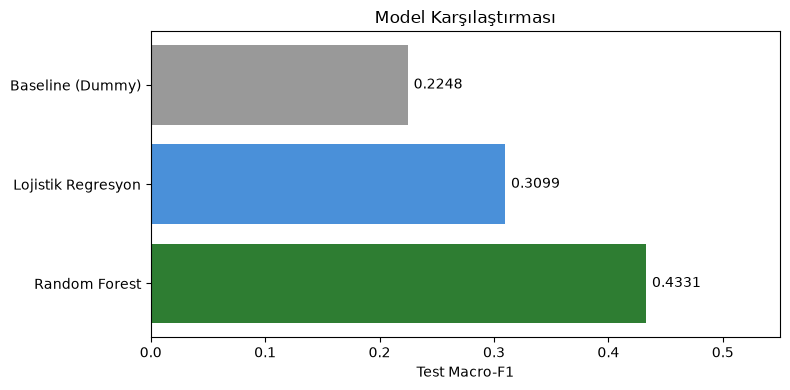

In [55]:
import matplotlib.pyplot as plt
import os

os.makedirs("../grafikler", exist_ok=True)   # klasör yoksa oluştur

sonuc = pd.DataFrame({
    "Model": ["Baseline (Dummy)", "Lojistik Regresyon", "Random Forest"],
    "Tip": ["Referans", "Doğrusal", "Ağaç tabanlı"],
    "Test Macro-F1": [skor_baseline, skor_lr, skor_rf],
    "Accuracy": [
        accuracy_score(y_test, d_test),
        accuracy_score(y_test, lr_test),
        accuracy_score(y_test, rf_test),
    ],
}).round(4)

print(sonuc.to_string(index=False))
print(f"\nEn iyi model: {sonuc.loc[sonuc['Test Macro-F1'].idxmax(), 'Model']}")

plt.figure(figsize=(8, 4))
renkler = ["#999999", "#4A90D9", "#2E7D32"]
plt.barh(sonuc["Model"], sonuc["Test Macro-F1"], color=renkler)
for i, v in enumerate(sonuc["Test Macro-F1"]):
    plt.text(v + 0.005, i, f"{v:.4f}", va="center")
plt.xlabel("Test Macro-F1")
plt.title("Model Karşılaştırması")
plt.xlim(0, 0.55)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../grafikler/08_model_karsilastirma.png", dpi=150)
plt.show()